# CNN Model

### Import packages and load data

In [1]:
%reload_ext autoreload
%autoreload 2
%aimport -numpy, -pandas, -matplotlib

import sys
import yaml
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import matplotlib.pyplot as plt
# use same font as latex
# plt.rc('text', usetex=True)

plt.rc('font', family='serif')

import pandas as pd
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
from dataset.utils.fungi_vis import FungiTasticVis

from types import SimpleNamespace
# import SimpleNamespace

#  fix random seeds for reproducibility
import random
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf
from tqdm import tqdm
from tensorflow import keras
from pathlib import Path
from collections import Counter
import cv2
random.seed(0)
np.random.seed(0)

/Users/danielmotoc/anaconda3/envs/tf_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
valset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='val',
        size='300',
        task='open',
        data_subset='Mini',
        transform=None,
)

trainset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='train',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

testset = FungiTasticVis(
        root=f"{os.getcwd()}/dataset/FungiTastic/",
        split='test',
        size='300',
        task='closed',
        data_subset='Mini',
        transform=None,
)

### Data preprocessing

In this code chunk, I am defining functions that first extract the training paths and labels from the datasets loaded above, and then define a function that creates a tf.dataset so that not all images need to be loaded into memory at once (will slow computer or crash).

In [ ]:
def extract_paths_and_labels(ds):
    """Extract file paths and labels."""
    paths, labels = [], []
    for i in tqdm(range(len(ds)), desc="Indexing"):
        _, y, p = ds[i]  # (PIL_image, label, path)
        paths.append(str(p))
        if y is None:
            labels.append(None)
        else:
            labels.append(int(y))  
    return paths, labels


def get_top_labels(labels, top_n=20):
    label_counts = Counter(labels)
    top_labels = [label for label, _ in label_counts.most_common(top_n)]
    print(f"Top {top_n} species (labels): {top_labels}")
    return set(top_labels)


def filter_by_labels(paths, labels, allowed_labels):
    filtered = [(p, y) for p, y in zip(paths, labels) if y in allowed_labels]
    f_paths, f_labels = zip(*filtered)
    return list(f_paths), list(f_labels)

# Train
train_paths, train_labels = extract_paths_and_labels(trainset)
top_labels = get_top_labels(train_labels, top_n=20)
train_paths, train_labels = filter_by_labels(train_paths, train_labels, top_labels)

# Validation
val_paths, val_labels = extract_paths_and_labels(valset)
val_paths, val_labels = filter_by_labels(val_paths, val_labels, top_labels)

# Test
test_paths, test_labels = extract_paths_and_labels(testset)



Indexing: 100%|██████████| 46842/46842 [01:11<00:00, 655.38it/s]


Top 20 species (labels): [83, 53, 44, 33, 39, 179, 29, 109, 177, 85, 78, 8, 24, 144, 50, 1, 15, 79, 207, 2]


Indexing: 100%|██████████| 10738/10738 [00:19<00:00, 565.11it/s]


In [1]:
autotune   = tf.data.AUTOTUNE
batch_size      = 64
h, w = 224, 224

def decode_and_resize_from_path(path):
    bytes_ = tf.io.read_file(path)
    img = tf.image.decode_image(bytes_, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [h, w],
                          method=tf.image.ResizeMethod.LANCZOS5)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = tf.cast(img, tf.float32) / 255.0
    return img

NameError: name 'tf' is not defined

In [ ]:
top_labels = np.unique(train_labels)

label_map = {old: new for new, old in enumerate(top_labels)}

label_map_tf = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(list(label_map.keys()),   dtype=tf.int64),
        values=tf.constant(list(label_map.values()), dtype=tf.int64),
    ),
    default_value=tf.constant(-1, dtype=tf.int64)  
)

def make_supervised_ds(paths, labels, training=True, shuffle_buf=10_000):
    """
    Creates a tf.data.Dataset:
      - reads (path, label)
      - decodes/resizes image
      - (re)maps label via label_map_tf to contiguous [0..n_classes-1]
      - optional flip augmentation
      - batches & prefetches
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(shuffle_buf, reshuffle_each_iteration=True)

    def _load_and_map(p, y):
        x = decode_and_resize_from_path(p)                      
        y = tf.cast(y, tf.int64)
        y = label_map_tf.lookup(y)                              

        tf.debugging.assert_greater_equal(y, tf.constant(0, tf.int64),
                                          message="Label not in label_map (got -1).")
        return x, tf.cast(y, tf.int32)

    autotune = tf.data.AUTOTUNE
    ds = ds.map(_load_and_map, num_parallel_calls=autotune)

    def _normalize(x, y):
        x = tf.image.convert_image_dtype(x, tf.float32)  # scales to [0,1]
        return x, y
    ds = ds.map(_normalize, num_parallel_calls=autotune)
    ds = ds.ignore_errors()
    
    if training:
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y),
                    num_parallel_calls=autotune)

    batch_size = 64 
    ds = ds.batch(batch_size, drop_remainder=training).prefetch(autotune)

    opts = tf.data.Options(); opts.experimental_deterministic = False
    return ds.with_options(opts)


train_ds = make_supervised_ds(train_paths, train_labels, training=True)
val_ds   = make_supervised_ds(val_paths,   val_labels,   training=False)


In [37]:
#Sanity check
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("dtype:", images.dtype)
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (64, 224, 224, 3)
Label batch shape: (64,)
dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 1.0


### Baseline Model: Majority Class Predictor

In [34]:
majority_label = label_map[Counter(train_labels).most_common(1)[0][0]]
print("Majority class:", majority_label)

Majority class: 13


In [38]:
def majority_accuracy(dataset, majority_label):
    total = 0
    correct = 0
    for i, (_, y) in enumerate(dataset):
        y_np = y.numpy()
        pred = np.full_like(y_np, fill_value=majority_label)
        correct += (pred == y_np).sum()
        total += y_np.size
    return correct / total

maj_train_acc = majority_accuracy(train_ds, majority_label)
maj_val_acc   = majority_accuracy(val_ds,   majority_label)
print(f"Majority baseline — train = {maj_train_acc:.3f}, val={maj_val_acc:.3f}")

Majority baseline — train = 0.092, val=0.057


### CNN baseline - no metadata

In [39]:
n_classes = len(np.unique(train_labels))

# define early stopping class
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy', 
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

/Users/danielmotoc/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn_multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,828 (374.33 KB)

 Trainable params: 95,828 (374.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
    279/Unknown 54s 188ms/step - accuracy: 0.1063 - loss: 2.9055

/Users/danielmotoc/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


279/279 ━━━━━━━━━━━━━━━━━━━━ 57s 201ms/step - accuracy: 0.1330 - loss: 2.8347 - val_accuracy: 0.1768 - val_loss: 2.6421
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.1759 - loss: 2.7021 - val_accuracy: 0.1718 - val_loss: 2.6732
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.1857 - loss: 2.6692 - val_accuracy: 0.2339 - val_loss: 2.5850
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 56s 199ms/step - accuracy: 0.1957 - loss: 2.6333 - val_accuracy: 0.2513 - val_loss: 2.5248
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.2116 - loss: 2.5913 - val_accuracy: 0.2216 - val_loss: 2.5519
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 55s 198ms/step - accuracy: 0.2190 - loss: 2.5675 - val_accuracy: 0.2656 - val_loss: 2.4596
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 56s 199ms/step - accuracy: 0.2301 - loss: 2.5341 - val_accuracy: 0.2592 - val_loss: 2.4717
Epoch 8/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 56s 199ms/step - accuracy: 0.2395 - loss: 2.5144 - val

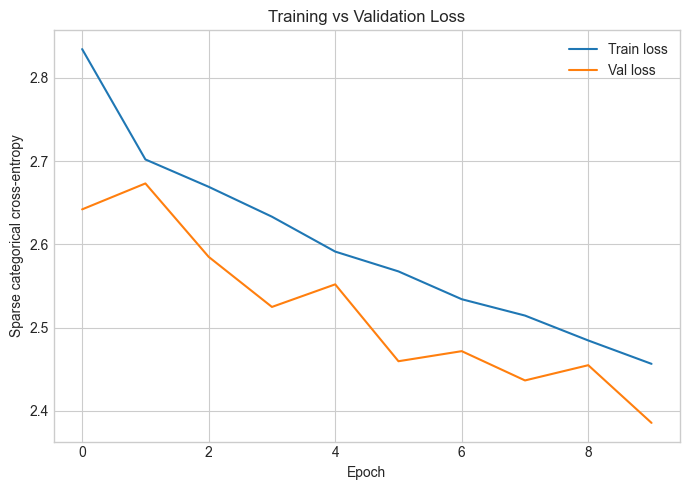

Train accuracy: 0.2708 | Val accuracy: 0.2918


In [ ]:
tf.random.set_seed(1234)
np.random.seed(1234)

baseline_cnn = tf.keras.Sequential(name="baseline_cnn_multi")

baseline_cnn.add(tf.keras.layers.Conv2D(
    filters=32, kernel_size=(3,3), strides=(1,1), padding='same',
    activation='relu', name='conv_1', input_shape=(224,224,3)
))
baseline_cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

baseline_cnn.add(tf.keras.layers.Conv2D(
    filters=64, kernel_size=(3,3), strides=(1,1), padding='same',
    activation='relu', name='conv_2'
))
baseline_cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

baseline_cnn.add(tf.keras.layers.Conv2D(
    filters=128, kernel_size=(3,3), strides=(1,1), padding='same',
    activation='relu', name='conv_3'
))
baseline_cnn.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

# Regularization
baseline_cnn.add(tf.keras.layers.Dropout(rate=0.4))
baseline_cnn.add(tf.keras.layers.GlobalAveragePooling2D())
baseline_cnn.add(tf.keras.layers.Dense(n_classes, activation='softmax'))


baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


baseline_cnn.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True
)

history = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Sparse categorical cross-entropy')
plt.title('Training vs Validation Loss'); plt.legend(); plt.tight_layout(); plt.show()

train_loss, train_acc = baseline_cnn.evaluate(train_ds, verbose=0)
val_loss,   val_acc   = baseline_cnn.evaluate(val_ds,   verbose=0)
print(f"Train accuracy: {train_acc:.4f} | Val accuracy: {val_acc:.4f}")